In [1]:
!pip install osmnx networkx folium geopandas shapely pyproj geopy

In [2]:
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
ox.settings.use_cache = True
ox.settings.log_console = True

In [4]:
place_name = "Bangalore, Karnataka, India"

G = ox.graph_from_place(
    place_name,
    network_type="drive",
    simplify=True
)

In [5]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 155373
Edges: 393729


In [6]:
nodes, edges = ox.graph_to_gdfs(G)

print(nodes.head())

                  y          x  street_count          highway junction  ref  \
osmid                                                                         
17327095  12.910542  77.598721             4              NaN      NaN  NaN   
17327139  12.934965  77.624072             3              NaN      NaN  NaN   
17327141  12.938493  77.629168             3              NaN      NaN  NaN   
17327420  13.095224  77.594178             3  traffic_signals      NaN  NaN   
17327433  12.985951  77.579325             3              NaN      NaN  NaN   

                           geometry  
osmid                                
17327095  POINT (77.59872 12.91054)  
17327139  POINT (77.62407 12.93497)  
17327141  POINT (77.62917 12.93849)  
17327420  POINT (77.59418 13.09522)  
17327433  POINT (77.57932 12.98595)  


In [7]:
print(edges.head())

                             osmid      highway lanes                  name  \
u        v         key                                                        
17327095 248007842 0      32261256  residential     2         2nd Main Road   
         305154531 0    1367650597    secondary     2        9th Cross Road   
17327139 443224605 0     111814615      primary     2  Mahayogi Vemana Road   
         309593057 0      28186701  residential   NaN        7th Cross Road   
17327141 956271706 0       8656177  residential   NaN         3rd Main Road   

                        oneway reversed      length  \
u        v         key                                
17327095 248007842 0      True    False  244.091315   
         305154531 0      True    False   29.723619   
17327139 443224605 0      True    False   44.630750   
         309593057 0     False    False   50.303992   
17327141 956271706 0     False     True  100.510660   

                                                            

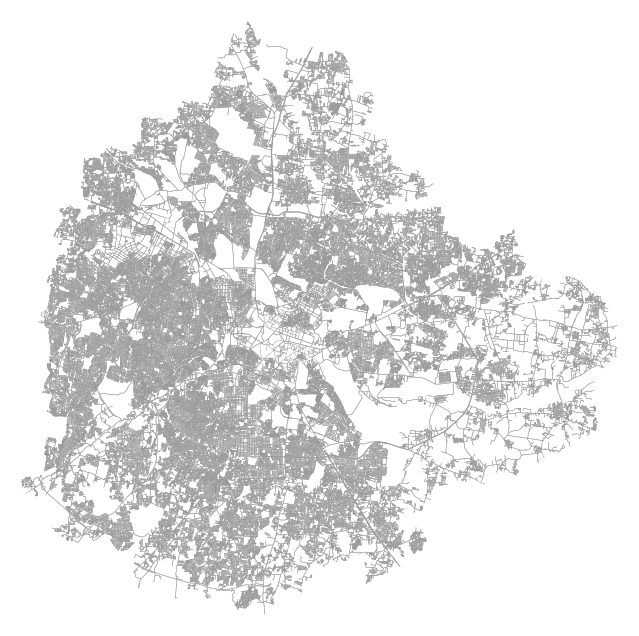

In [8]:
fig, ax = ox.plot_graph(
    G,
    bgcolor="white",
    node_size=0,
    edge_linewidth=0.3
)

In [9]:
G = ox.routing.add_edge_speeds(G)

In [10]:
sample_edge = list(G.edges(data=True))[0]

print(sample_edge)

(17327095, 248007842, {'osmid': 32261256, 'highway': 'residential', 'lanes': '2', 'name': '2nd Main Road', 'oneway': True, 'reversed': False, 'length': np.float64(244.09131521234454), 'speed_kph': 28.230263157894736})


In [11]:
G = ox.routing.add_edge_travel_times(G)

In [12]:
edge = list(G.edges(data=True))[0]

print(edge)

(17327095, 248007842, {'osmid': 32261256, 'highway': 'residential', 'lanes': '2', 'name': '2nd Main Road', 'oneway': True, 'reversed': False, 'length': np.float64(244.09131521234454), 'speed_kph': 28.230263157894736, 'travel_time': 31.127188926635963})


In [13]:
edge_lengths = [
    data["length"]
    for u,v,data in G.edges(data=True)
]

print("Average Road Length:",
      np.mean(edge_lengths))

Average Road Length: 61.56208079576122


In [14]:
ox.save_graphml(
    G,
    "bangalore_graph.graphml"
)

In [15]:
G2 = ox.load_graphml(
    "bangalore_graph.graphml"
)

print(len(G2.nodes))

155373


In [16]:
m = folium.Map(
    location=[12.9716,77.5946],
    zoom_start=12
)

m

In [17]:
nodes, edges = ox.graph_to_gdfs(G)

folium.GeoJson(
    edges.head(500).to_json()
).add_to(m)

m

In [18]:
m.save(
    "bangalore_digital_twin.html"
)

Event Mapping Engine

In [19]:
df = pd.read_csv(
    "/content/Astram_event_data_anonymized_Astram_event_data_anonymizedb40ac87.csv"
)

print(df.shape)

df.head()

(8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [20]:
df[['latitude','longitude']].head()

,latitude,longitude
0,13.040004,77.518099
1,12.921876,77.645158
2,12.955622,77.585708
3,13.006147,77.579435
4,12.953980,77.585233


In [21]:
df = df.dropna(
    subset=['latitude','longitude']
)

In [22]:
sample_event = df.iloc[0]

event_lat = sample_event['latitude']
event_lon = sample_event['longitude']

print(event_lat,event_lon)

13.0400041 77.5180991


In [23]:
event_node = ox.distance.nearest_nodes(
    G,
    X=event_lon,
    Y=event_lat
)

print(event_node)

6033543907


In [24]:
G.nodes[event_node]

{'y': 13.0400509, 'x': 77.5180784, 'street_count': 3}

In [25]:
m = folium.Map(
    location=[event_lat,event_lon],
    zoom_start=15
)

folium.Marker(
    [event_lat,event_lon],
    popup="Traffic Event"
).add_to(m)

m

In [26]:
node_lat = G.nodes[event_node]['y']
node_lon = G.nodes[event_node]['x']

folium.CircleMarker(
    [node_lat,node_lon],
    radius=8,
    popup="Mapped Node"
).add_to(m)

m

In [27]:
def map_event_to_network(
    latitude,
    longitude,
    graph
):

    nearest_node = ox.distance.nearest_nodes(
        graph,
        X=longitude,
        Y=latitude
    )

    return nearest_node

In [28]:
node = map_event_to_network(
    event_lat,
    event_lon,
    G
)

print(node)

6033543907


In [ ]:
df['nearest_node'] = df.apply(

    lambda row:

    map_event_to_network(
        row['latitude'],
        row['longitude'],
        G
    ),

    axis=1
)